# (노트) CNN, 아이유와 지드래곤 

- toc:true
- branch: master
- badges: true
- comments: true
- author: 신록예찬
- hide: false
- categories: [데이터과학]

In [1]:
import tensorflow as tf

In [2]:
import tensorflow.experimental.numpy as tnp

In [3]:
tnp.experimental_enable_numpy_behavior()

In [4]:
import numpy as np

In [5]:
import requests
import re
import json
from PIL import Image

In [6]:
import matplotlib.pyplot as plt 

In [7]:
def search_images_ddg(key,max_n=200):
    """Search for 'key' with DuckDuckGo and return a unique urls of 'max_n' images
       (Adopted from https://github.com/deepanprabhu/duckduckgo-images-api)
    """
    url        = 'https://duckduckgo.com/'
    params     = {'q':key}
    res        = requests.post(url,data=params)
    searchObj  = re.search(r'vqd=([\d-]+)\&',res.text)
    if not searchObj: print('Token Parsing Failed !'); return
    requestUrl = url + 'i.js'
    headers    = {'User-Agent': 'Mozilla/5.0 (X11; Ubuntu; Linux x86_64; rv:71.0) Gecko/20100101 Firefox/71.0'}
    params     = (('l','us-en'),('o','json'),('q',key),('vqd',searchObj.group(1)),('f',',,,'),('p','1'),('v7exp','a'))
    urls       = []
    while True:
        try:
            res  = requests.get(requestUrl,headers=headers,params=params)
            data = json.loads(res.text)
            for obj in data['results']:
                urls.append(obj['image'])
                max_n = max_n - 1
                if max_n < 1: return list(set(urls))     # dedupe
            if 'next' not in data: return list(set(urls))
            requestUrl = url + data['next']
        except:
            pass        

In [8]:
# from fastcore.all import * 

In [9]:
# def download_images(dest, url_file=None, urls=None, max_pics=1000, n_workers=8, timeout=4, preserve_filename=False):
#     "Download images listed in text file `url_file` to path `dest`, at most `max_pics`"
#     if urls is None: urls = url_file.read_text().strip().split("\n")[:max_pics]
#     dest = Path(dest)
#     dest.mkdir(exist_ok=True)
#     parallel(partial(_download_image_inner, dest, timeout=timeout, preserve_filename=preserve_filename),
#              L(enumerate(urls)), n_workers=n_workers, threadpool=True)

In [10]:
# class partial:
#     """New function with partial application of the given arguments
#     and keywords.
#     """

#     __slots__ = "func", "args", "keywords", "__dict__", "__weakref__"

#     def __new__(cls, func, /, *args, **keywords):
#         if not callable(func):
#             raise TypeError("the first argument must be callable")

#         if hasattr(func, "func"):
#             args = func.args + args
#             keywords = {**func.keywords, **keywords}
#             func = func.func

#         self = super(partial, cls).__new__(cls)

#         self.func = func
#         self.args = args
#         self.keywords = keywords
#         return self

#     def __call__(self, /, *args, **keywords):
#         keywords = {**self.keywords, **keywords}
#         return self.func(*self.args, *args, **keywords)

#     @recursive_repr()
#     def __repr__(self):
#         qualname = type(self).__qualname__
#         args = [repr(self.func)]
#         args.extend(repr(x) for x in self.args)
#         args.extend(f"{k}={v!r}" for (k, v) in self.keywords.items())
#         if type(self).__module__ == "functools":
#             return f"functools.{qualname}({', '.join(args)})"
#         return f"{qualname}({', '.join(args)})"

#     def __reduce__(self):
#         return type(self), (self.func,), (self.func, self.args,
#                self.keywords or None, self.__dict__ or None)

#     def __setstate__(self, state):
#         if not isinstance(state, tuple):
#             raise TypeError("argument to __setstate__ must be a tuple")
#         if len(state) != 4:
#             raise TypeError(f"expected 4 items in state, got {len(state)}")
#         func, args, kwds, namespace = state
#         if (not callable(func) or not isinstance(args, tuple) or
#            (kwds is not None and not isinstance(kwds, dict)) or
#            (namespace is not None and not isinstance(namespace, dict))):
#             raise TypeError("invalid partial state")

#         args = tuple(args) # just in case it's a subclass
#         if kwds is None:
#             kwds = {}
#         elif type(kwds) is not dict: # XXX does it need to be *exactly* dict?
#             kwds = dict(kwds)
#         if namespace is None:
#             namespace = {}

#         self.__dict__ = namespace
#         self.func = func
#         self.args = args
#         self.keywords = kwds

In [11]:
# !pip install fastcore

### 이미지 크롤링의 개요 

`-` "검색 -> 이미지주소 -> 저장" 을 반복하면 된다. 

### get url: 검색 -> 이미지주소

In [12]:
iu_lst = search_images_ddg('iu',max_n=500)

In [13]:
iu_lst[:5]

['https://6.viki.io/image/cbe8defd9b584ccbb62603fc04922fd5.jpeg?s=900x600&e=t',
 'https://k-luv.leonparenzo.com/wp-content/uploads/2020/05/iu-confessed-why-she-tears-up-every-time-her-fans-sing-her-songs-and-her-reason-is-not-what-you-think-1.jpg',
 'https://www.koreaboo.com/wp-content/uploads/2016/11/iu8.jpg',
 'https://images4.alphacoders.com/564/thumb-1920-564903.jpg',
 'https://1.bp.blogspot.com/-9GriRq2oDzk/XkuLt1Vg7dI/AAAAAAAATHQ/ss65om-lr-McUoM-bunev2QcVx3mUSvvgCLcBGAsYHQ/s1600/_fL1Gu3S%2B%25282%2529.jpg']

In [14]:
# download_images('.',search_images_ddg('iu',max_n=5))

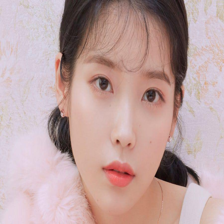

In [15]:
img=Image.open(Image.io.BytesIO(requests.get(iu_lst[0]).content))
img=img.resize((224,224))
img

In [16]:
X = np.array(img).reshape(1,224,224,3)

In [17]:
X

array([[[[216, 204, 218],
         [216, 204, 218],
         [216, 204, 218],
         ...,
         [209, 199, 201],
         [206, 197, 192],
         [200, 191, 192]],

        [[216, 204, 218],
         [218, 206, 220],
         [218, 206, 220],
         ...,
         [210, 201, 194],
         [208, 201, 187],
         [205, 197, 187]],

        [[218, 206, 220],
         [217, 205, 219],
         [217, 205, 219],
         ...,
         [211, 201, 196],
         [207, 199, 187],
         [200, 192, 180]],

        ...,

        [[217, 206, 215],
         [221, 210, 219],
         [227, 212, 225],
         ...,
         [225, 205, 220],
         [228, 207, 221],
         [229, 208, 225]],

        [[219, 209, 217],
         [221, 210, 219],
         [228, 213, 227],
         ...,
         [228, 207, 222],
         [228, 208, 220],
         [229, 208, 224]],

        [[223, 213, 221],
         [222, 210, 219],
         [227, 212, 225],
         ...,
         [233, 212, 227],
        

### 이미지주소 -> 저장 

In [18]:
import tqdm

In [19]:
for url in tqdm.tqdm(iu_lst[1:]): 
    try: 
        img=Image.open(Image.io.BytesIO(requests.get(url).content))
        img=img.resize((224,224))
        X= np.concatenate([X,np.array(img).reshape(1,224,224,3)],axis=0)
    except: 
        pass
        #print(url)

100%|██████████| 469/469 [06:52<00:00,  1.14it/s]  


In [20]:
X.shape

(455, 224, 224, 3)

In [21]:
y=[0]*X.shape[0]

In [22]:
gdragon_lst = search_images_ddg('gdragon',max_n=500)

In [23]:
for url in tqdm.tqdm(gdragon_lst): 
    try: 
        img=Image.open(Image.io.BytesIO(requests.get(url).content))
        img=img.resize((224,224))
        X= np.concatenate([X,np.array(img).reshape(1,224,224,3)],axis=0)
    except: 
        pass
        #print(url)

100%|██████████| 444/444 [14:51<00:00,  2.01s/it]  


In [24]:
y= y+[1]*(X.shape[0]-len(y))

In [25]:
y=tf.keras.utils.to_categorical(y)
y

array([[1., 0.],
       [1., 0.],
       [1., 0.],
       ...,
       [0., 1.],
       [0., 1.],
       [0., 1.]], dtype=float32)

In [1]:
Xtr= X[5:-5]/255 
Xtst = tf.concat([X[:5],X[-5:]],axis=0)/255
#Xtst = tf.constant(Xtst,dtype=tf.float64)

NameError: name 'X' is not defined

In [ ]:
ytr= y[5:-5]
ytst = tf.concat([y[:5],y[-5:]],axis=0)

In [ ]:
net1= tf.keras.Sequential()
net1.add(tf.keras.layers.Conv2D(30,(5,5),activation='relu'))
net1.add(tf.keras.layers.Conv2D(30,(5,5),activation='relu'))
net1.add(tf.keras.layers.AveragePooling2D())
net1.add(tf.keras.layers.BatchNormalization())
net1.add(tf.keras.layers.Conv2D(30,(5,5),activation='relu'))
net1.add(tf.keras.layers.Conv2D(30,(5,5),activation='relu'))
net1.add(tf.keras.layers.AveragePooling2D())
net1.add(tf.keras.layers.BatchNormalization())
net1.add(tf.keras.layers.Flatten())
net1.add(tf.keras.layers.Dense(2,activation='softmax'))

In [ ]:
net1.compile(optimizer=tf.optimizers.Adam(), loss=tf.losses.categorical_crossentropy,metrics='accuracy')

In [ ]:
net1.fit(Xtr,ytr,epochs=10,batch_size=1)

In [ ]:
net1.evaluate(Xtst,ytst)

In [ ]:
net2 = tf.keras.applications.ResNet50V2(weights=None,classes=2)

In [ ]:
net2.compile(optimizer=tf.optimizers.Adam(), loss=tf.losses.categorical_crossentropy,metrics='accuracy')

In [ ]:
net2.fit(Xtr,ytr,epochs=10)

In [ ]:
net2.evaluate(Xtst,ytst)